# Codigo baseado no Kaggle

https://www.kaggle.com/code/agajorte/sat-6-aerial-images-classification

## Importação das bibliotecas

Carrega as bibliotecas essenciais: `pandas` (manipulação de dados), `numpy` (operações numéricas), `matplotlib` (gráficos) e `tensorflow` (deep learning). O comando `%matplotlib inline` faz os gráficos aparecerem logo abaixo das células.

In [1]:
# carregar as bibliotecas básicas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


from sklearn.model_selection import train_test_split
from datetime import datetime


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# gerar os gráficos logo abaixo dos comandos de plot
%matplotlib inline

I0000 00:00:1783268455.127487    5133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783268455.128942    5133 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783268455.266785    5133 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783268458.846336    5133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Configuração da GPU (NVIDIA RTX)

Detecta a GPU, ativa o crescimento de memória sob demanda (`set_memory_growth`, evita a TF reservar toda a VRAM de uma vez) e liga o **mixed precision** (`mixed_float16`), que usa os *Tensor Cores* da RTX para treinar **~2-3x mais rápido** gastando metade da memória. Precisa rodar **antes** de criar qualquer modelo — por isso fica logo após os imports. Como consequência, a camada de saída dos modelos é fixada em `float32` (estabilidade numérica do softmax).

In [ ]:
# --- Configuracao da GPU (NVIDIA RTX) ---
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponiveis:", gpus)
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)   # aloca VRAM sob demanda

# mixed precision: aproveita os Tensor Cores da RTX (treino mais rapido, metade da VRAM)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Politica de precisao:", mixed_precision.global_policy().name)

## Definição dos caminhos dos arquivos

Define os caminhos dos arquivos CSV de treino e teste do dataset **SAT-6**, separando os **dados** (X — imagens) dos **rótulos** (y — classes).

In [2]:

x_TRAIN_path = 'data/ds_train/X_train_sat6.csv' #data
y_TRAIN_path = 'data/ds_train/y_train_sat6.csv' #label

x_TEST_path = 'data/ds_test/X_test_sat6.csv' #data
y_TEST_path = 'data/ds_test/y_test_sat6.csv' #label


## Carregamento dos dados

Lê os CSVs com `pandas`. Como agora rodamos em **GPU**, carregamos o **treino completo do SAT-6 (324 000 imagens)** e o **teste no split padrão (81 000)** — só o teste usa `nrows`. Cada linha de dados traz 3136 colunas de pixels (28×28×4) e cada rótulo tem 6 colunas (one-hot); `dtype='uint8'` mantém os pixels como inteiros de 0–255, economizando memória. O carregamento completo pode levar ~1–2 min e ocupa ~1 GB de RAM.

In [3]:
#train_data = pd.read_csv(train_data_path, header=None, dtype='uint8', nrows=32400)
train_data = pd.read_csv(x_TRAIN_path, header=None, dtype='uint8')              # treino completo (324k)
print("Train data shape: ", train_data.shape)

#train_label = pd.read_csv(y_TRAIN_path, header=None, dtype='uint8', nrows=32400)
train_label = pd.read_csv(y_TRAIN_path, header=None, dtype='uint8')

print("Train label shape:", train_label.shape)
print()

#test_data = pd.read_csv(x_TEST_path, header=None, dtype='uint8', nrows=8100)
test_data = pd.read_csv(x_TEST_path, header=None, dtype='uint8', nrows=81000)   # teste padrao SAT-6

print("Test data shape: ", test_data.shape)

#test_label = pd.read_csv(test_label_path, header=None, dtype='uint8', nrows=8100)
test_label = pd.read_csv(y_TEST_path, header=None, dtype='uint8', nrows=81000)

print("Test label shape:", test_label.shape)

Train data shape:  (25000, 3136)
Train label shape: (25000, 6)

Test data shape:  (25000, 3136)
Test label shape: (25000, 6)


## Visualização dos dados de treino

Mostra as 5 primeiras linhas de `train_data`. Cada linha é uma imagem achatada em 3136 valores de pixel (28 × 28 × 4).

In [4]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,116,119,118,159,108,113,118,150,67,60,...,21,80,56,47,38,94,69,67,61,103
1,177,152,129,183,180,154,128,182,181,156,...,128,171,182,164,135,173,182,160,136,174
2,20,34,72,10,27,45,76,13,39,92,...,81,8,47,127,93,9,58,137,102,12
3,102,92,136,20,134,156,144,33,135,162,...,69,5,27,51,67,6,36,54,73,6
4,122,140,156,34,124,155,151,32,135,165,...,157,34,113,142,151,24,101,115,149,21


## Visualização dos rótulos de treino

Mostra as 5 primeiras linhas de `train_label`. Os rótulos estão em formato **one-hot**: 6 colunas, com o valor 1 na coluna da classe correspondente.

In [5]:
train_label.head()

,0,1,2,3,4,5
0,0,0,1,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


## Remodelagem para imagens

Cada linha do CSV é um vetor achatado de 3136 valores; `reshape([-1, 28, 28, 4])` reorganiza esses números de volta para imagens de 28×28 com 4 canais (R, G, B, NIR). O `-1` deixa o NumPy inferir a quantidade de imagens, gerando tensores `(25000, 28, 28, 4)` — exatamente o formato que as camadas `Conv2D` esperam na entrada.

In [6]:
x_train = train_data.values.reshape([-1,28,28,4])
x_test = test_data.values.reshape([-1,28,28,4])

x_train.shape, x_test.shape

((25000, 28, 28, 4), (25000, 28, 28, 4))

## Definição das classes

Define os nomes das 6 classes de cobertura do solo e conta a quantidade de classes.

In [7]:


class_names = ['Construção', 'Estrada', 'Pastagem', 'Solo exposto', 'Água', 'Árvores']
class_count = len(class_names)

print("Quantidade de classes: %d" % class_count)
print("Nomes das classes:", class_names)



Quantidade de classes: 6
Nomes das classes: ['Construção', 'Estrada', 'Pastagem', 'Solo exposto', 'Água', 'Árvores']


## Rótulos em formato one-hot

Exibe novamente as primeiras linhas dos rótulos de treino, antes da conversão para índice único.

In [8]:
train_label.head(5) #.apply(label_converter, axis=1)

,0,1,2,3,4,5
0,0,0,1,0,0,0
1,0,1,0,0,0,0
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


## Função de conversão de rótulos

Define `label_converter`, que transforma o rótulo one-hot (6 colunas) em um único índice inteiro de classe (0 a 5), ajustando a ordem das colunas para o mapeamento das classes. A última linha testa a função nas 10 primeiras amostras.

In [9]:
#Converter formato dos rótulos¶

# {0: 'Construção', 1: 'Estrada', 2: 'Pastagem', 3: 'Solo exposto', 4: 'Água', 5: 'Árvores'}

def label_converter(values):
  if values[0] == 1:    # Building / Construção
    return 0
  elif values[1] == 1:  # Barren land / Solo exposto
    return 3
  elif values[2] == 1:  # Trees / Árvores
    return 5
  elif values[3] == 1:  # Grassland / Pastagem
    return 2
  elif values[4] == 1:  # Road / Estrada
    return 1
  elif values[5] == 1:  # Water / Água
    return 4
  else:
    return None

train_label.head(10).apply(label_converter, axis=1)



0    5
1    3
2    4
3    4
4    4
5    0
6    0
7    4
8    3
9    5
dtype: int64

## Vetor de rótulos de treino

Aplica `label_converter` a todos os rótulos de treino, gerando o vetor `y_train` com os índices de classe (0–5).

In [10]:
y_train = train_label.apply(label_converter, axis=1).values.ravel().astype('uint8')
#y_train = train_label.values.ravel().astype('uint8')
#y_train = train_label.apply(label_converter, axis=1).astype('category')
y_train

array([5, 3, 4, ..., 2, 3, 2], shape=(25000,), dtype=uint8)

## Vetor de rótulos de teste

Mesma conversão aplicada aos rótulos de teste, gerando o vetor `y_test`.

In [11]:
y_test = test_label.apply(label_converter, axis=1).values.ravel().astype('uint8')
#y_test = test_label.values.ravel().astype('uint8')
#y_test = test_label.apply(label_converter, axis=1).astype('category')
y_test


array([5, 5, 4, ..., 4, 3, 2], shape=(25000,), dtype=uint8)

## Verificação dos tipos de dados

Confirma que os dados e os rótulos estão no tipo `uint8` (inteiros de 0 a 255), o que economiza memória.

In [ ]:
print(f"x_train  ->  dtype: {x_train.dtype} | min: {x_train.min()} | max: {x_train.max()}")
print(f"y_train  ->  dtype: {y_train.dtype} | classes: {np.unique(y_train)}")

## Uso de memória

Calcula e exibe o consumo de memória (MB/kB) de cada array de dados e rótulos.

In [13]:


print("x_train: %5d MB" % np.ceil(x_train.nbytes / 1024 / 1024))
print("y_train: %5d kB" % np.ceil(y_train.nbytes / 1024))
print("x_test:  %5d MB" % np.ceil(x_test.nbytes / 1024 / 1024))
print("y_test:  %5d kB" % np.ceil(y_test.nbytes / 1024))

x_train:    75 MB
y_train:    25 kB
x_test:     75 MB
y_test:     25 kB


## Liberação de memória

Remove da memória os DataFrames originais do pandas, já que os dados agora estão armazenados nos arrays NumPy (`x_train`, `x_test`, etc.).

In [14]:
del train_data
del train_label
del test_data
del test_label

## Conferência dos formatos (treino)

Verifica os formatos finais de `x_train` (imagens) e `y_train` (rótulos).

In [ ]:
print(f"Treino  ->  x: {x_train.shape}   |   y: {y_train.shape}")

## Conferência dos formatos (teste)

Verifica os formatos finais de `x_test` (imagens) e `y_test` (rótulos).

In [ ]:
print(f"Teste   ->  x: {x_test.shape}   |   y: {y_test.shape}")

## Distribuição de classes no treino

`np.unique(..., return_counts=True)` conta quantas amostras existem por classe (0–5). No SAT-6 as classes são bastante **desbalanceadas** (coberturas como Água e Árvores tendem a ser muito mais comuns que Estrada). Esse desbalanceamento justifica o `stratify` no split e o uso de métricas ponderadas mais adiante, para o modelo não ficar enviesado às classes majoritárias.

In [ ]:
# distribuição de classes no treino
classes, contagens = np.unique(y_train, return_counts=True)
total = contagens.sum()
print(f"Treino - {total} amostras em {len(classes)} classes:\n")
for c, qtd in zip(classes, contagens):
    barra = '#' * round(30 * qtd / contagens.max())
    print(f"  {class_names[c]:<13} {qtd:>7d}  {qtd/total:6.1%}  {barra}")

## Distribuição de classes no teste

Conta as amostras por classe no conjunto de teste, mostrando um desbalanceamento semelhante ao observado no treino.

In [ ]:
# distribuição de classes no teste
classes, contagens = np.unique(y_test, return_counts=True)
total = contagens.sum()
print(f"Teste - {total} amostras em {len(classes)} classes:\n")
for c, qtd in zip(classes, contagens):
    barra = '#' * round(30 * qtd / contagens.max())
    print(f"  {class_names[c]:<13} {qtd:>7d}  {qtd/total:6.1%}  {barra}")

## Função de visualização de amostras

Define `show_samples`, que exibe uma grade de 32 imagens aleatórias (RGB) com o nome da classe de cada uma. O `suptitle` resume as informações do dataset (nº de amostras, dimensões e distribuição por classe).

In [19]:
def show_samples(data, labels):
    fig = plt.figure(figsize=(16, 8))
    ax = []
    rows, columns = 4, 8

    # informacoes do dataset para o suptitle
    n_amostras = len(labels)
    classes, contagens = np.unique(labels, return_counts=True)
    distribuicao = " | ".join(
        "%s: %d" % (class_names[c], qtd) for c, qtd in zip(classes, contagens)
    )
    fig.suptitle(
        "Dataset SAT-6  —  %d amostras  •  imagens 28×28×4 (RGB+NIR)  •  %d classes\n"
        "Distribuição por classe: %s" % (n_amostras, len(class_names), distribuicao),
        fontsize=14, y=1.03,
    )

    for i in range(columns * rows):
        index = np.random.randint(1, 500)
        img = data[index].reshape([28,28,4])[:,:,:3]
        class_name = class_names[labels[index]]
        ax.append(fig.add_subplot(rows, columns, i+1))
        ax[-1].set_title(class_name)
        plt.axis("off")
        plt.imshow(img)

    plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()

## Amostras do conjunto de treino

Executa `show_samples` sobre os dados de treino.

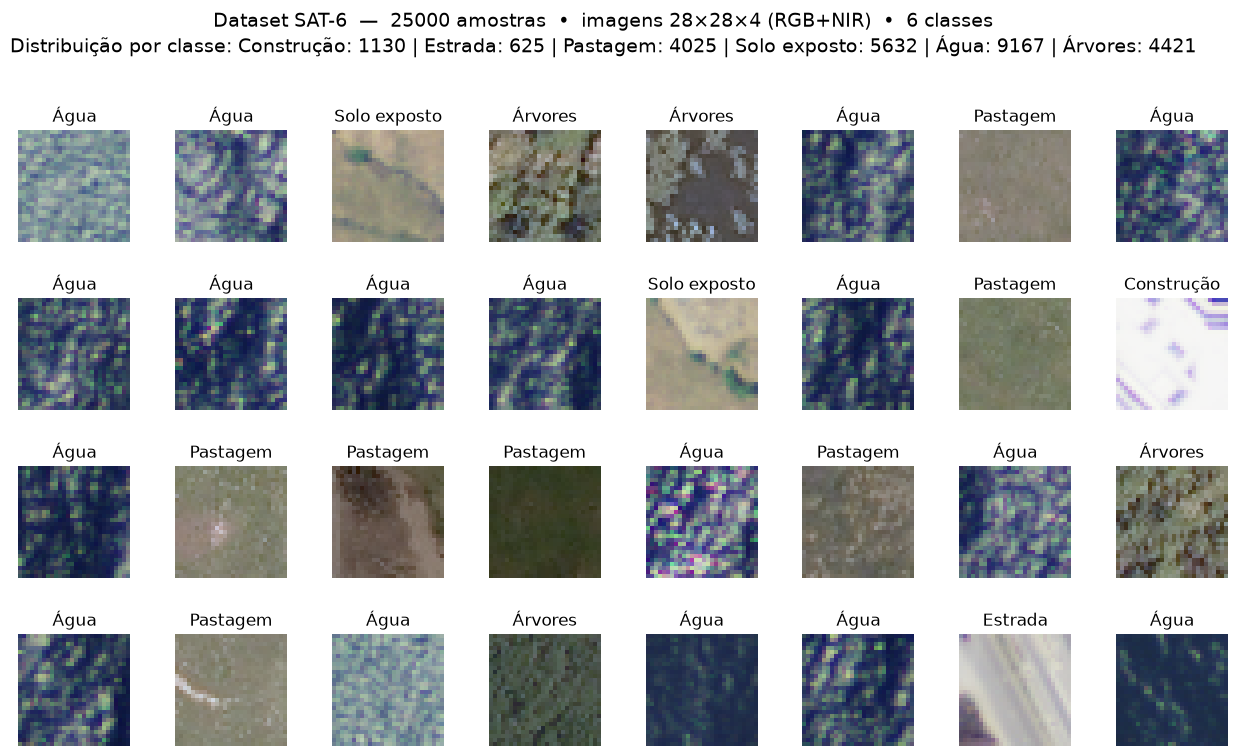

In [20]:
show_samples(x_train, y_train)

## Função de histograma de uma amostra

Define `show_sample_histogram`, que mostra uma imagem (RGB) ao lado do histograma de intensidade dos seus 4 canais (R, G, B, NIR).

In [21]:


def show_sample_histogram(data, labels, index=None):

    if not index:
        index = np.random.randint(1, len(labels))

    fig = plt.figure(figsize=(12, 6))
    ax = []
    rows, columns = 1, 2
    colors = ("red", "green", "blue", "purple")
    channel_ids = (0, 1, 2, 3)

    all = data[index].reshape([28, 28, 4])

    class_name = class_names[labels[index]]
    rgb = all[:,:,:3]
    ax.append(fig.add_subplot(rows, columns, 1))
    ax[-1].set_title(class_name, fontsize=20)
    plt.axis("off")
    plt.imshow(rgb)

    ax.append(fig.add_subplot(rows, columns, 2))
    ax[-1].set_xlim([0, 256])
    for channel_id, c in zip(channel_ids, colors):
        histogram, bin_edges = np.histogram(
            all[:, :, channel_id], bins=256, range=(0, 256))
        ax[-1].plot(bin_edges[0:-1], histogram, color=c, linewidth=0.8)
        ax[-1].set_title('Histograma dos pixels', fontsize=20)
        ax[-1].legend(['R', 'G', 'B', 'NIR'])

    fig.tight_layout()

    #plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()



## Histograma de uma amostra de treino

Executa a função em uma amostra aleatória do conjunto de treino.

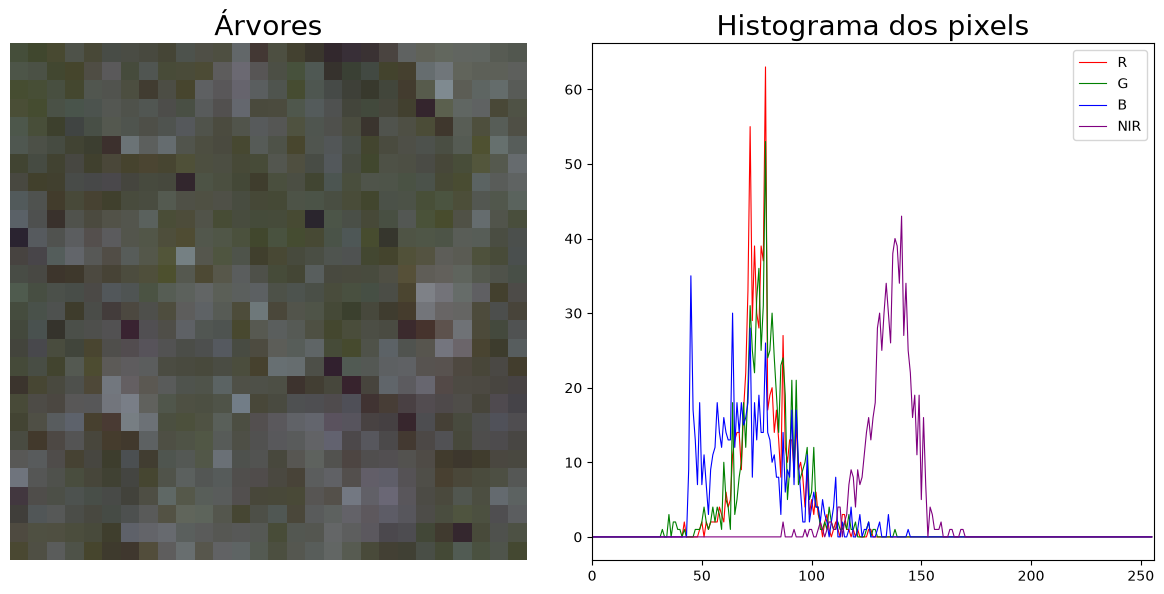

In [22]:
show_sample_histogram(x_train, y_train)

## Histograma de uma amostra de teste

Executa a função na primeira amostra (`index=0`) do conjunto de teste.

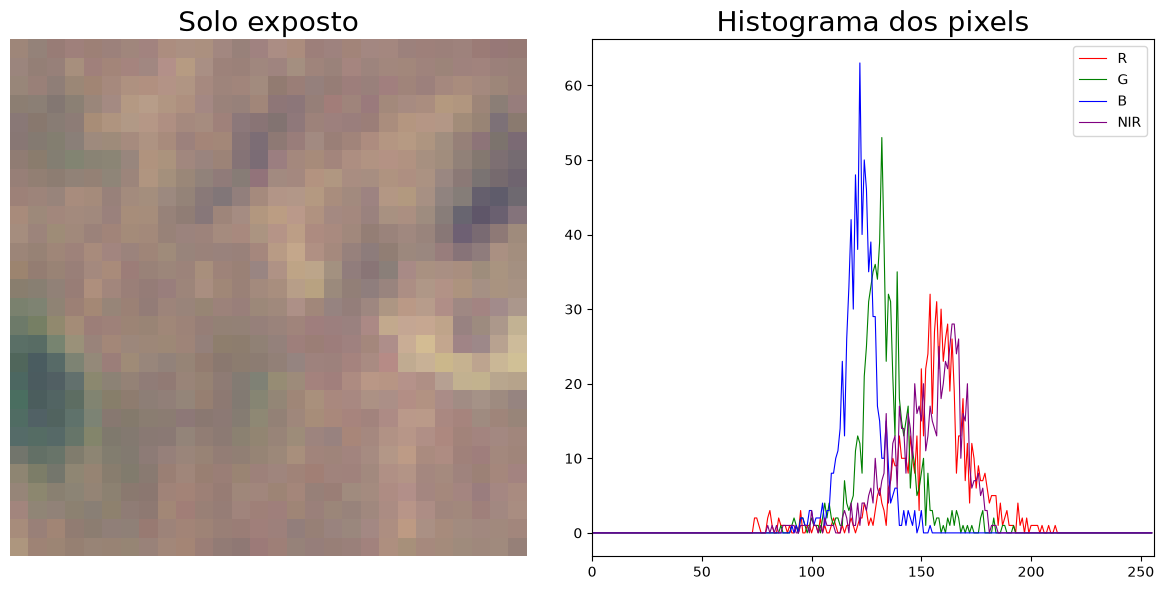

In [23]:
show_sample_histogram(x_test, y_test, index=0)

## Histograma de uma classe específica

Define `show_class_histogram`, uma variação de `show_sample_histogram` na qual **você escolhe a classe** a ser plotada — pelo índice (0–5) ou pelo nome (ex.: `'Água'`). A função sorteia uma amostra daquela classe e mostra a imagem RGB ao lado do histograma dos 4 canais (R, G, B, NIR). O `suptitle` informa a classe e quantas amostras existem dela no conjunto.

In [24]:
def show_class_histogram(data, labels, class_type):

    # aceita o indice da classe (0-5) ou o nome da classe (ex.: 'Água')
    if isinstance(class_type, str):
        if class_type not in class_names:
            print("Classe inválida:", class_type, "- use uma de:", class_names)
            return
        class_number = class_names.index(class_type)
    else:
        class_number = class_type

    # buscar todos os indices que pertencem a classe escolhida
    indices = np.where(labels == class_number)[0]
    if len(indices) == 0:
        print("Nenhuma amostra encontrada para a classe:", class_names[class_number])
        return

    # sortear uma amostra dessa classe
    index = np.random.choice(indices)

    fig = plt.figure(figsize=(12, 6))
    ax = []
    rows, columns = 1, 2
    colors = ("red", "green", "blue", "purple")
    channel_ids = (0, 1, 2, 3)

    all = data[index].reshape([28, 28, 4])

    class_name = class_names[labels[index]]
    rgb = all[:,:,:3]
    ax.append(fig.add_subplot(rows, columns, 1))
    ax[-1].set_title(class_name, fontsize=20)
    plt.axis("off")
    plt.imshow(rgb)

    ax.append(fig.add_subplot(rows, columns, 2))
    ax[-1].set_xlim([0, 256])
    for channel_id, c in zip(channel_ids, colors):
        histogram, bin_edges = np.histogram(
            all[:, :, channel_id], bins=256, range=(0, 256))
        ax[-1].plot(bin_edges[0:-1], histogram, color=c, linewidth=0.8)
        ax[-1].set_title('Histograma dos pixels', fontsize=20)
        ax[-1].legend(['R', 'G', 'B', 'NIR'])

    fig.suptitle(
        "Classe: %s  •  %d amostras nesta classe  •  amostra #%d"
        % (class_name, len(indices), index),
        fontsize=14,
    )

    fig.tight_layout()
    plt.show()

## Exemplo de uso

Plota uma amostra da classe escolhida. Você pode passar o **nome** (`'Água'`) ou o **índice** (`4`).

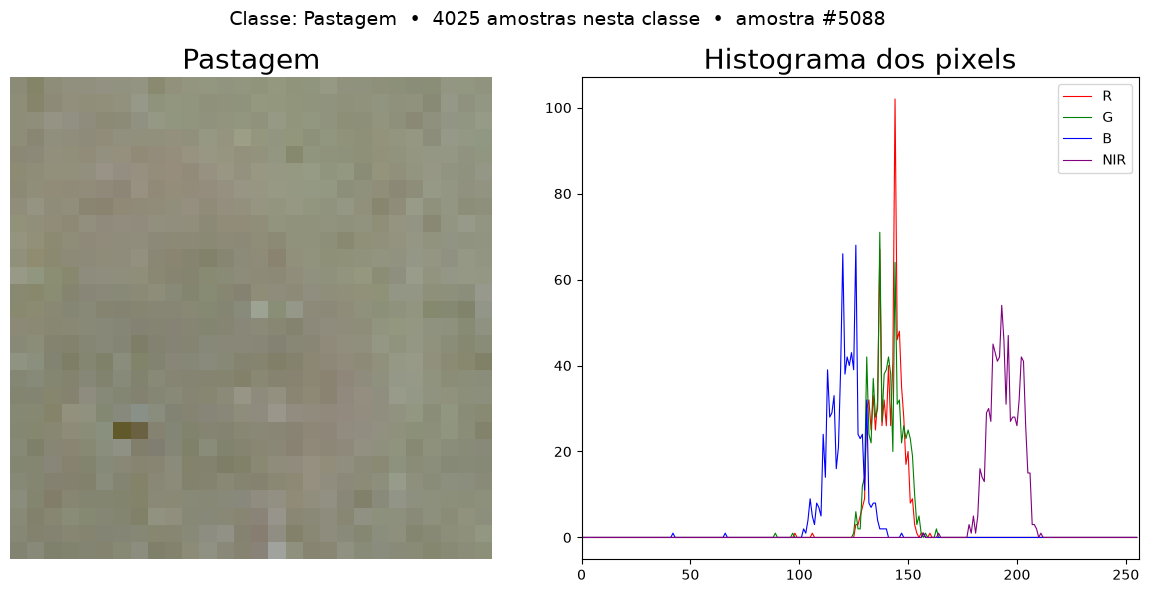

In [25]:
# pelo nome da classe
show_class_histogram(x_train, y_train, 'Pastagem')

# ou pelo indice da classe (0=Construção, 1=Estrada, 2=Pastagem, 3=Solo exposto, 4=Água, 5=Árvores)
# show_class_histogram(x_train, y_train, 1)

## Função de comparação espectral por classe

Define `show_histogram_samples`, que seleciona uma amostra de cada classe e exibe, por linha: a imagem RGB, os canais R/G/B/NIR separados e o histograma dos 4 canais. O `suptitle` resume as informações do dataset. Útil para comparar as **assinaturas espectrais** das classes.

In [26]:
def show_histogram_samples(data, labels):

    # buscar uma amostra de cada classe
    sample_indices = []
    class_counter = 0
    while class_counter < class_count:
        index = np.random.randint(1, 500)
        class_number = labels[index]
        if class_number == class_counter:
            class_counter += 1
            sample_indices.append(index)
            continue
    print("sample indices:", sample_indices)

    colors = ("red", "green", "blue", "purple")
    channel_ids = (0, 1, 2, 3)

    fig = plt.figure(figsize=(18, 12))
    
    # informacoes do dataset para o suptitle
    n_amostras = len(labels)
    classes, contagens = np.unique(labels, return_counts=True)
    distribuicao = " | ".join(
        "%s: %d" % (class_names[c], qtd) for c, qtd in zip(classes, contagens)
    )
    fig.suptitle(
        "Dataset SAT-6  \u2014  %d amostras  \u2022  4 canais espectrais (R, G, B, NIR)  \u2022  %d classes\n"
        "Distribui\u00e7\u00e3o por classe: %s" % (n_amostras, len(class_names), distribuicao),
        fontsize=16, y=1.01,
    )
    ax = []
    rows, columns = 6, 6
    class_counter = 0

    # plotar imagem RGB, canais separados e histograma de cada classe
    for i in range(rows):
        index = sample_indices[class_counter]
        class_counter += 1
        all = data[index].reshape([28,28,4])
        
        class_name = class_names[labels[index]]
        rgb = all[:,:,:3]
        ax.append(fig.add_subplot(rows, columns, i * columns + 1))
        ax[-1].set_title(class_name)
        plt.axis("off")
        plt.imshow(rgb)
        plt.colorbar()

        red = all[:,:,0]
        ax.append(fig.add_subplot(rows, columns, i * columns + 2))
        ax[-1].set_title("Red")
        plt.axis("off")
        plt.imshow(red, cmap="Reds")
        plt.colorbar()

        green = all[:,:,1]
        ax.append(fig.add_subplot(rows, columns, i * columns + 3))
        ax[-1].set_title("Green")
        plt.axis("off")
        plt.imshow(green, cmap="Greens")
        plt.colorbar()

        blue = all[:,:,2]
        ax.append(fig.add_subplot(rows, columns, i * columns + 4))
        ax[-1].set_title("Blue")
        plt.axis("off")
        plt.imshow(blue, cmap="Blues")
        plt.colorbar()

        nir = all[:,:,2]
        ax.append(fig.add_subplot(rows, columns, i * columns + 5))
        ax[-1].set_title("NIR")
        plt.axis("off")
        plt.imshow(nir, cmap="inferno")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 6))
        ax[-1].set_xlim([0, 256])
        for channel_id, c in zip(channel_ids, colors):
            histogram, bin_edges = np.histogram(
                all[:, :, channel_id], bins=256, range=(0, 256))
            ax[-1].plot(bin_edges[0:-1], histogram, color=c, linewidth=0.8)

    fig.tight_layout()

    #plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()

## Comparação espectral — treino

Executa `show_histogram_samples` sobre o conjunto de treino.

sample indices: [395, 435, 106, 64, 414, 326]


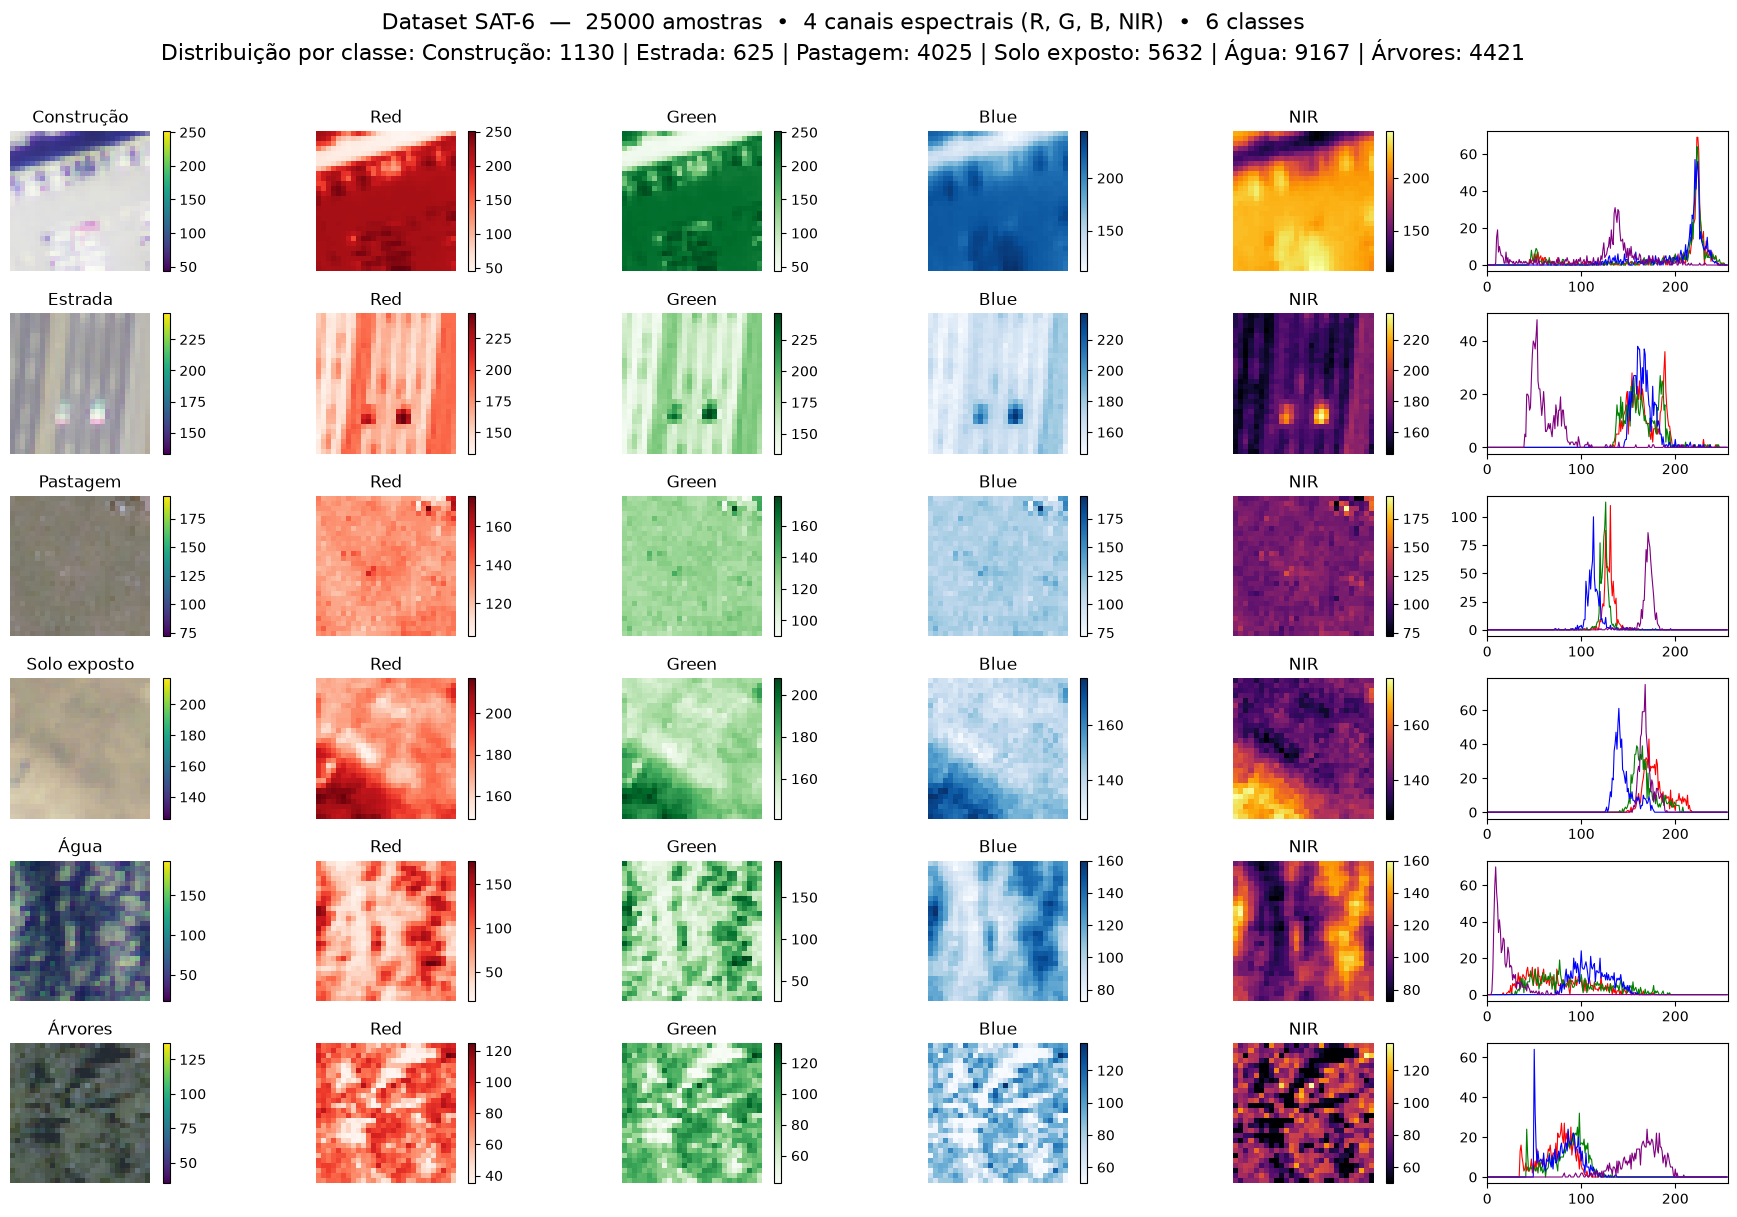

In [27]:
show_histogram_samples(x_train, y_train)

## Comparação espectral — teste

Executa `show_histogram_samples` sobre o conjunto de teste.

sample indices: [187, 64, 140, 307, 390, 499]


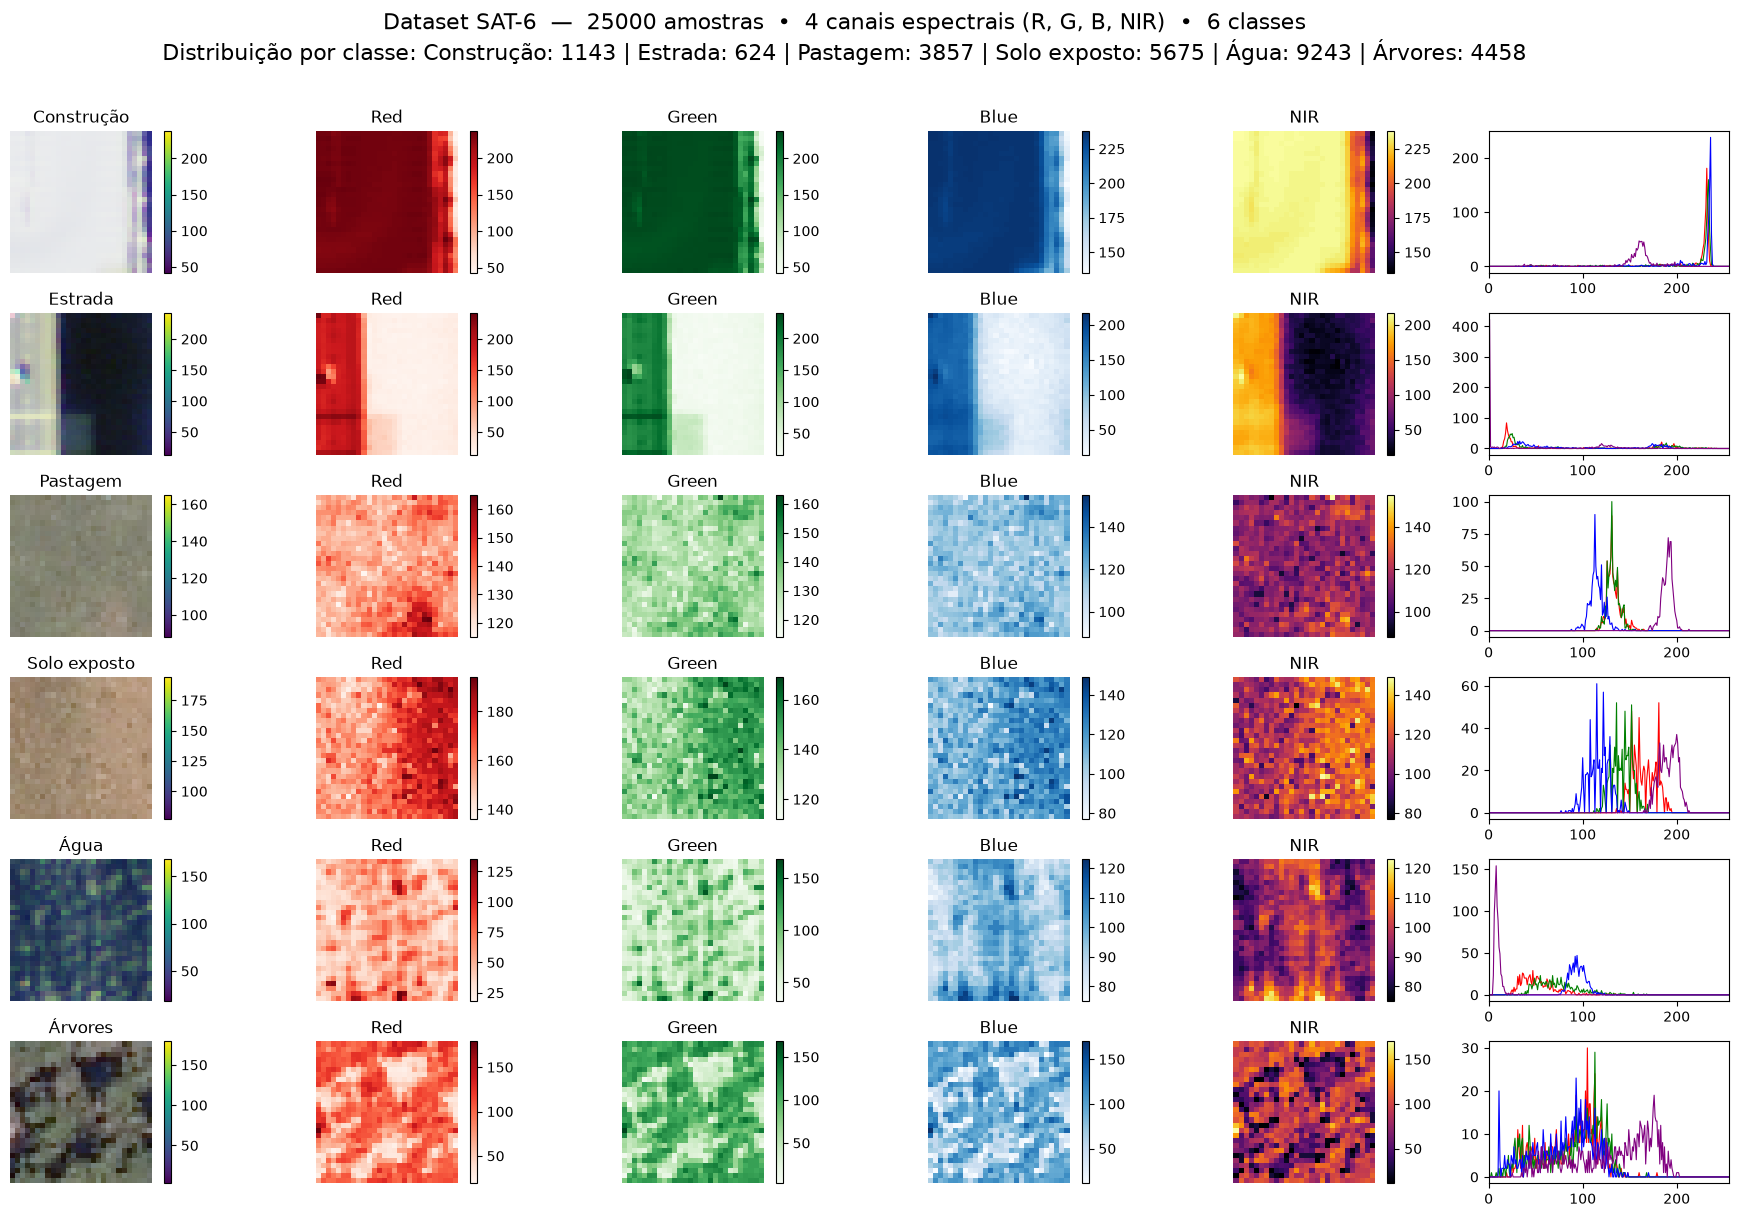

In [28]:
show_histogram_samples(x_test, y_test)


### Pré-processamento dos dados



Criação de atributos

### Função: visualização de índices espectrais

Define `show_spectral_indices_samples`, que seleciona uma amostra de cada classe e calcula, a partir dos canais R/G/B/NIR, cinco **índices espectrais**: **NDVI** (vegetação), **NDWI** (água), **NDBI** (área construída), **MNDBI** e **SAVI** (vegetação ajustado ao solo). Plota, por linha, a imagem RGB e cada índice em um mapa de cores próprio — útil para comparar como cada índice realça diferentes tipos de cobertura.

#### Por que usar índices espectrais

As imagens do SAT-6 têm 4 canais: **R, G, B e NIR** (infravermelho próximo). Sozinhos, os valores brutos de cada canal são pouco discriminativos — uma pastagem e uma árvore podem ter R/G/B parecidos. Os **índices espectrais** combinam os canais em razões que realçam propriedades físicas dos alvos, separando as classes muito melhor que os canais crus.

O padrão mais usado é a **diferença normalizada** `(A − B) / (A + B)`, que destaca o contraste entre dois canais e normaliza variações de iluminação/sombra (resultado sempre entre −1 e 1).

| Índice | Fórmula | Realça | Ajuda a separar |
|--------|---------|--------|-----------------|
| **NDVI** | (NIR − R)/(NIR + R) | Vegetação saudável | Árvores/Pastagem vs. resto |
| **NDWI** | (G − NIR)/(G + NIR) | Água | Água vs. terra |
| **NDBI** | (R − G)/(R + G) | Área construída / solo | Construção/Solo exposto |
| **MNDBI** | (NIR − B)/(NIR + B) | Variante para construído | Refina áreas urbanas |
| **SAVI** | (NIR − R)·1.5/(NIR + R + 0.5) | Vegetação corrigindo o solo | Vegetação esparsa sobre solo |

O **NIR é o canal-chave**: vegetação reflete muito NIR e água quase nada — algo invisível no RGB, mas evidente nesses índices.

**Impacto no processamento:** é *feature engineering* com conhecimento de domínio. Em vez de esperar a rede descobrir essas razões sozinha, já entregamos atributos mais informativos e robustos a brilho/sombra, o que melhora a separabilidade das classes. É exatamente o que a função `generate_indices` faz a seguir.

In [29]:
def show_spectral_indices_samples(data, labels):
    np.seterr(divide='ignore')
    fig = plt.figure(figsize=(16, 8))
    ax = []
    rows, columns = 6, 7
    class_counter = 0
    for i in range(rows):

        while True:
            index = np.random.randint(1, 500)
            class_number = labels[index]
            if class_number == class_counter:
                class_counter += 1
                break

        all = data[index].reshape([28,28,4])
        rgb = all[:,:,:3]
        red = all[:,:,0] / 255
        green = all[:,:,1] / 255
        blue = all[:,:,2] / 255
        nir = all[:,:,3] / 255

        ndvi = (nir - red) / (nir + red)
        ndwi = (green - nir) / (green + nir)
        ndbi = (red - green) / (red + green)
        mndbi = (nir - blue) / (nir + blue)
        savi = (nir - red) * 1.5 / (nir + red + 0.5)

        class_name = class_names[labels[index]]
        ax.append(fig.add_subplot(rows, columns, i * columns + 1))
        ax[-1].set_title(class_name)
        plt.axis("off")
        plt.imshow(rgb)
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 2))
        ax[-1].set_title("NIR")
        plt.axis("off")
        plt.imshow(ndvi, cmap="inferno")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 3))
        ax[-1].set_title("NDVI")
        plt.axis("off")
        plt.imshow(ndvi, cmap="RdYlGn")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 4))
        ax[-1].set_title("NDWI")
        plt.axis("off")
        plt.imshow(ndwi, cmap="PuBu")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 5))
        ax[-1].set_title("NDBI")
        plt.axis("off")
        plt.imshow(ndbi, cmap="jet")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 6))
        ax[-1].set_title("MNDBI")
        plt.axis("off")
        plt.imshow(mndbi, cmap="bwr")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 7))
        ax[-1].set_title("SAVI")
        plt.axis("off")
        plt.imshow(savi, cmap="RdYlBu")
        plt.colorbar()

    plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()

### Índices espectrais — treino

Executa `show_spectral_indices_samples` sobre o conjunto de treino.

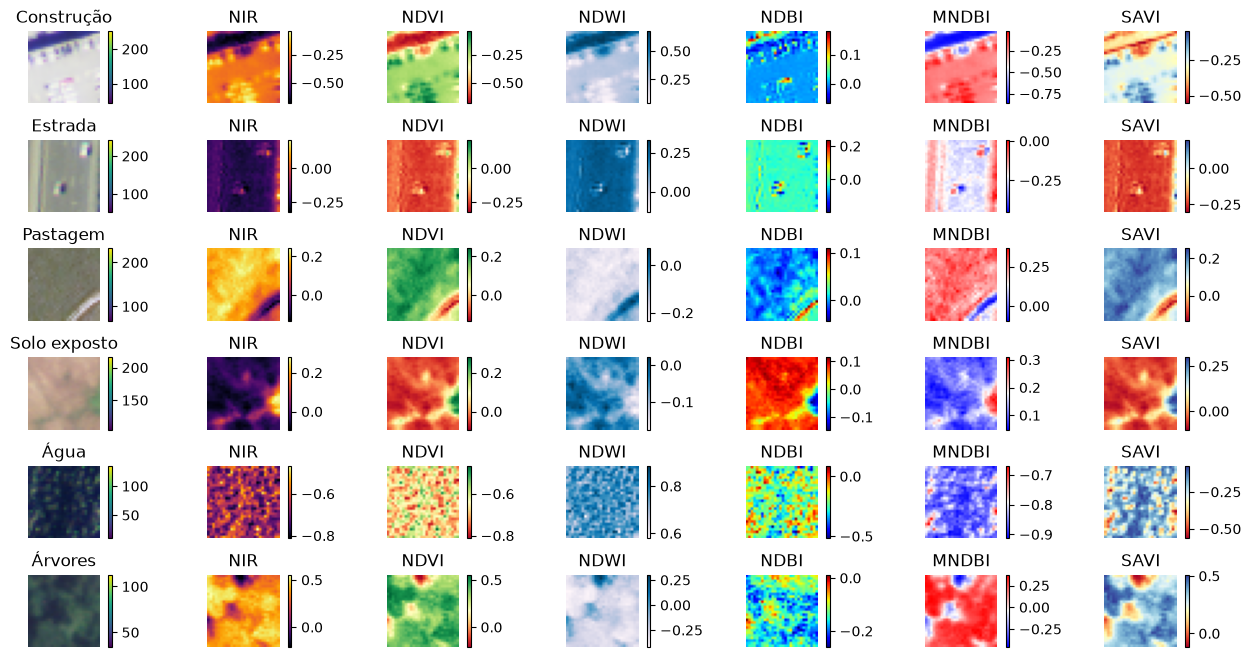

In [30]:
show_spectral_indices_samples(x_train, y_train)

### Índices espectrais — teste

Executa `show_spectral_indices_samples` sobre o conjunto de teste.

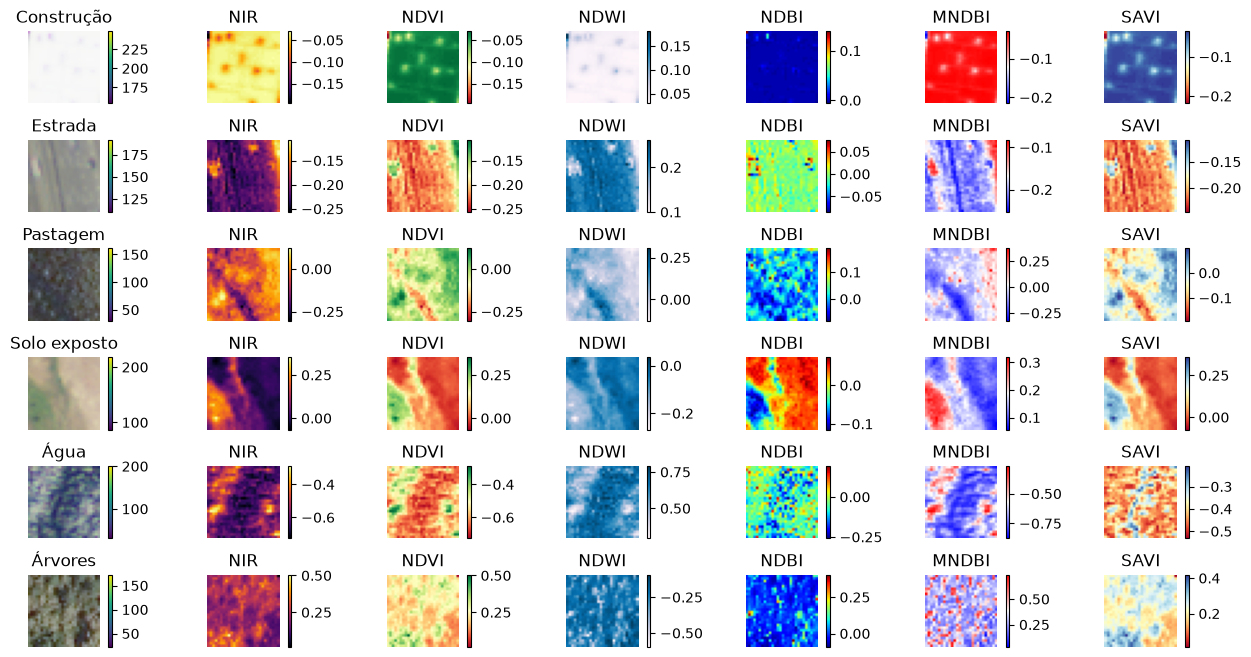

In [31]:
show_spectral_indices_samples(x_test, y_test)

### Função: geração de novos atributos (índices espectrais)

Define `generate_indices`, versão **vetorizada** que calcula 4 índices (NDVI, NDWI, NDBI, MNDBI) para todas as imagens de uma vez e os empilha em um tensor `(N, 28, 28, 4)`. Fica aqui como **referência / ponto de experimentação**: os modelos finais (3 e beta) usam os canais originais (R, G, B, NIR), mas você pode alimentar um modelo com esses índices trocando a entrada por `generate_indices(x_train)`.

In [32]:
def generate_indices(data):
  np.seterr(divide='ignore')

  red = data[:,:,:,0] / 255
  green = data[:,:,:,1] / 255
  blue = data[:,:,:,2] / 255
  nir = data[:,:,:,3] / 255

  ndvi = (nir - red) / (nir + red)
  ndwi = (green - nir) / (green + nir)
  ndbi = (red - green) / (red + green)
  mndbi = (nir - blue) / (nir + blue)

  return np.stack((ndvi, ndwi, ndbi, mndbi), axis=-1)


#### Treinamento e validação dos modelos
Particionamento dos dados em treino, validação e teste

In [36]:
x_train_partial, x_validation, y_train_partial, y_validation = train_test_split(
    x_train, y_train, test_size=0.1, random_state=0, stratify=y_train)

# conferir quantidade de linhas
print(x_train_partial.shape)
print(x_validation.shape)
print(y_train_partial.shape)
print(y_validation.shape)


(22500, 28, 28, 4)
(2500, 28, 28, 4)
(22500,)
(2500,)


### Balanceamento do treino parcial

Conta as amostras por classe em `y_train_partial` após o split. Como o `train_test_split` usou `stratify=y_train`, a proporção entre as classes deve espelhar a do conjunto original — isso evita que o modelo aprenda enviesado para as classes mais frequentes.

In [ ]:
# balanceamento após o split (treino parcial)
classes, contagens = np.unique(y_train_partial, return_counts=True)
print("Treino parcial (apos split):")
for c, qtd in zip(classes, contagens):
    print(f"  {class_names[c]:<13} {qtd:>7d}  ({qtd/contagens.sum():5.1%})")

Mesma checagem para os 10% de validação: a distribuição deve refletir a do treino (efeito do `stratify`), garantindo que a acurácia de validação seja uma estimativa justa em todas as classes.

In [ ]:
# balanceamento do conjunto de validação
classes, contagens = np.unique(y_validation, return_counts=True)
print("Validacao:")
for c, qtd in zip(classes, contagens):
    print(f"  {class_names[c]:<13} {qtd:>7d}  ({qtd/contagens.sum():5.1%})")

### Fixação das sementes aleatórias (reprodutibilidade)

Define a mesma semente (`42`) para `PYTHONHASHSEED`, `random`, `numpy` e `tensorflow`. Isso torna o experimento **reprodutível**: a inicialização dos pesos, o embaralhamento dos lotes e o dropout passam a gerar sempre os mesmos números, então rodar o notebook de novo devolve praticamente os mesmos resultados — essencial para comparar os modelos de forma justa. Os blocos comentados no fim são configurações de sessão de versões antigas do TensorFlow, mantidas só como referência.

In [40]:
# Seed value
# Apparently you may use different seed values at each stage
seed_value = 42

# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED'] = str(seed_value)

# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)

# 3. Set the `numpy` pseudo-random generator at a fixed value
import numpy as np
np.random.seed(seed_value)

# 4. Set the `tensorflow` pseudo-random generator at a fixed value
import tensorflow as tf
tf.random.set_seed(seed_value)
# for later versions: 
# tf.compat.v1.set_random_seed(seed_value)

# 5. Configure a new global `tensorflow` session
#from keras import backend as K
#session_conf = tf.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
#sess = tf.Session(graph=tf.get_default_graph(), config=session_conf)
#K.set_session(sess)
# for later versions:
#session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
#sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
#tf.compat.v1.keras.backend.set_session(sess)

### Utilitário de treino: classe `TreinoModelo`

Classe auxiliar que guarda os dados de cada execução — `id`, preditor, tempo de treino, acurácia, perda e histórico. A função de treino logo abaixo usa essa classe para registrar cada modelo de forma organizada no `benchmark`.

In [44]:
class TreinoModelo:

  def __init__(self, id, preditor):
    self.id = id
    self.preditor = preditor
    self.inicio_tempo = None
    self.duracao = None
    self.acuracia = None
    self.perda = None
    self.historico = None

  def __str__(self):
    return f"{self.id}: {self.preditor}"

  # tempo de treino
  def iniciar_contagem_tempo(self):
    self.inicio_tempo = datetime.now()
  def finalizar_contagem_tempo(self):
    termino_tempo = datetime.now()
    duracao = (termino_tempo - self.inicio_tempo).total_seconds()
    self.duracao = duracao
  def obter_duracao(self):
    return self.duracao

  # acurácia
  def definir_acuracia(self, valor):
    self.acuracia = valor
  def obter_acuracia(self):
    return self.acuracia

  # perda
  def definir_perda(self, valor):
    self.perda = valor
  def obter_perda(self):
    return self.perda

  # histórico de execuções
  def definir_historico(self, valor):
    self.historico = valor
  def obter_historico(self):
    return self.historico

### Função de treino, validação e teste (com benchmark)

Versão avançada que orquestra o ciclo completo de cada modelo e alimenta o comparativo final:

- **`callbacks`**: `EarlyStopping` interrompe o treino quando a acurácia para de melhorar (evita épocas desperdiçadas — importante rodando em CPU) e `ModelCheckpoint` salva em disco a melhor versão pela `val_loss`.
- **Cronometragem e métricas** ficam encapsuladas no objeto `TreinoModelo`.
- **`benchmark[id]`** guarda `(acurácia, perda, tempo)` de cada modelo, e as globais `best_model`/`best_accuracy` são atualizadas sempre que um modelo bate o recorde. É assim que o restante do notebook sabe qual foi o melhor modelo.

In [45]:
best_model = None
best_accuracy = 0.0
benchmark = {}

def train_validate_and_test(id, model, x_train, y_train, x_val, y_val, x_test, y_test, epochs=10, batch_size=256): 
    global best_model, best_accuracy

    callbacks_list = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True)
    ]

    tm = TreinoModelo(id, model)
    tm.iniciar_contagem_tempo()

    history = model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size,
                        callbacks=callbacks_list,
                        validation_data=(x_val, y_val))

    tm.finalizar_contagem_tempo()

    print("Treinamento demorou %.1f segundos" % tm.obter_duracao())
    
    print(f"Avaliação do modelo:")
    results = model.evaluate(x_test, y_test)

    tm.definir_acuracia(results[1])
    tm.definir_perda(results[0])
    tm.definir_historico(history)

    last_accuracy = tm.obter_acuracia()
    benchmark[id] = (last_accuracy, tm.obter_perda(), tm.obter_duracao())

    if last_accuracy > best_accuracy:
        best_model = model
        best_accuracy = last_accuracy

    return tm


### Função de plotagem do histórico de treino

Define `plot_model_training_history`, que recebe o `history` do `model.fit` e desenha dois gráficos lado a lado: **perda** (treino × validação) e **acurácia** (treino × validação) por época. Comparar as duas curvas é o diagnóstico visual de **overfitting** — quando a curva de treino continua melhorando mas a de validação estagna ou piora, o modelo está decorando em vez de generalizar.

In [47]:
#Função para plotagem do histórico do treino


def plot_model_training_history(history):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    history_dict = history.history
    keys = list(history_dict.keys())

    loss_values = history_dict[keys[0]] # loss
    val_loss_values = history_dict[keys[2]] # val_loss
    epochs = range(1, len(history_dict[keys[0]]) + 1)

    ax1.plot(epochs, loss_values, 'bo', label='Training loss')
    ax1.plot(epochs, val_loss_values, 'b', label='Validation loss')
    ax1.set(title = 'Training and validation loss',
            xlabel = 'Epochs',
            ylabel = 'Loss')
    ax1.legend()

    acc_values = history_dict[keys[1]] # accuracy
    val_acc_values = history_dict[keys[3]] # val_accuracy

    ax2.plot(epochs, acc_values, 'bo', label='Training accuracy')
    ax2.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
    ax2.set(title = 'Training and validation accuracy',
            xlabel = 'Epochs',
            ylabel = 'Accuracy')
    ax2.legend()

    plt.show()

### Modelo 2 — CNN com camada densa e dropout

Evolui o modelo 1: 64 filtros maiores (4×4) seguidos de `MaxPool2D(4,4)` (que reduz bastante a resolução), depois uma camada densa oculta de 196 neurônios com `Dropout(0.2)` antes da saída. A camada densa dá mais capacidade de combinar atributos e o dropout ajuda a conter o overfitting. Ainda treina com **pixels crus** (sem normalização).

In [50]:
def create_model2(class_count, print_summary=False):

  model = Sequential([
      Conv2D(64, (4,4), activation='relu', input_shape=(28, 28, 4)), # camada de convolução c/ 64 filtros 4x4
      MaxPool2D((4,4)),                                              # max pooling 4x4

      #Conv2D(32, (2,2), activation='relu'),                          # camada de convolução c/ 32 filtros 2x2
      #MaxPool2D((2,2)),                                              # max pooling 2x2

      Flatten(),                                                     # achatamento p/ entrar em MLP
      #Dropout(0.2),
      Dense(196, activation='relu'),                                 # camada oculta c/ 196 neurônios
      Dropout(0.2),                                                  # dropout de 20%

      Dense(class_count, activation='softmax', dtype='float32')                       # camada de saída c/ 6 neurônios
  ])

  model.compile('adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  if print_summary:
      model.summary()

  return model

### Treino do modelo 2 — desativado

Célula comentada. Treinaria o `create_model2` por 50 épocas com validação. Descomente as linhas para executá-lo e registrá-lo no `benchmark`.

In [51]:

# model = create_model2(class_count, print_summary=True)
# tm = train_validate_and_test('2', model, x_train_partial, y_train_partial, 
#                              x_validation, y_validation, x_test, y_test, epochs=50)



Plotagem do histórico do modelo 2 — comentada, acompanha a célula acima.

In [52]:
#plot_model_training_history(tm.obter_historico())

### Melhor modelo do cara



In [53]:
def create_model3(class_count, print_summary=False):

  model = Sequential([
      Conv2D(64, (4,4), activation='relu', input_shape=(28, 28, 4)), # camada de convolução c/ 64 filtros 4x4
      #MaxPool2D((4,4)),                                              # max pooling 4x4

      Conv2D(32, (2,2), activation='relu'),                          # camada de convolução c/ 32 filtros 2x2
      MaxPool2D((2,2)),                                              # max pooling 2x2

      Conv2D(32, (2,2), activation='relu'),                          # camada de convolução c/ 32 filtros 2x2

      Conv2D(32, (2,2), activation='relu'),                          # camada de convolução c/ 32 filtros 2x2
      MaxPool2D((2,2)),                                              # max pooling 2x2

      Flatten(),                                                     # achatamento p/ entrar em MLP
      Dropout(0.2),
      #Dense(196, activation=tf.nn.relu),                             # camada oculta c/ 196 neurônios
      Dense(class_count, activation='softmax', dtype='float32')                       # camada de saída c/ 6 neurônios
  ])

  model.compile('adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  if print_summary:
      model.summary()

  return model

### Treino do modelo 3

Treina o `create_model3` (a melhor arquitetura da referência do Kaggle) por até 50 épocas com `train_validate_and_test`, registrando resultado e tempo no `benchmark`. O `EarlyStopping` deve cortar antes das 50 épocas assim que a acurácia estabilizar.

In [54]:

model = create_model3(class_count, print_summary=True)
tm = train_validate_and_test('3', model, x_train_partial, y_train_partial, 
                             x_validation, y_validation, x_test, y_test, epochs=50)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         4,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,446 (99.40 KB)

 Trainable params: 25,446 (99.40 KB)

 Non-trainable params: 0 (0.00 B)

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9683 - loss: 0.0898 - val_accuracy: 0.9768 - val_loss: 0.0624
Epoch 17/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9649 - loss: 0.0944

704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9649 - loss: 0.0944 - val_accuracy: 0.9772 - val_loss: 0.0610
Epoch 18/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9664 - loss: 0.0918 - val_accuracy: 0.9764 - val_loss: 0.0642
Epoch 19/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9699 - loss: 0.0836 - val_accuracy: 0.9484 - val_loss: 0.1403
Epoch 20/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9699 - loss: 0.0818 - val_accuracy: 0.9636 - val_loss: 0.0939
Epoch 21/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9712 - loss: 0.0822 - val_accuracy: 0.9652 - val_loss: 0.0894
Epoch 22/50
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9667 - loss: 0.0905

704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9666 - loss: 0.0907 - val_accuracy: 0.9796 - val_loss: 0.0598
Epoch 23/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9706 - loss: 0.0807 - val_accuracy: 0.9752 - val_loss: 0.0644
Epoch 24/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9669 - loss: 0.0889 - val_accuracy: 0.9712 - val_loss: 0.0727
Epoch 25/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9701 - loss: 0.0849 - val_accuracy: 0.9700 - val_loss: 0.0810
Epoch 26/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9721 - loss: 0.0757 - val_accuracy: 0.9744 - val_loss: 0.0795
Epoch 27/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9720 - loss: 0.0732 - val_accuracy: 0.9788 - val_loss: 0.0616
Epoch 28/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9707 - loss: 0.0804 - val_accuracy: 0.9712 - val_loss: 0.0833
Epoch 29/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.9726 - loss: 0.0736 - val_

704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9752 - loss: 0.0697 - val_accuracy: 0.9832 - val_loss: 0.0586
Epoch 34/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9754 - loss: 0.0653 - val_accuracy: 0.9772 - val_loss: 0.0704
Epoch 35/50
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9753 - loss: 0.0684

704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9753 - loss: 0.0683 - val_accuracy: 0.9780 - val_loss: 0.0568
Epoch 36/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9748 - loss: 0.0682 - val_accuracy: 0.9784 - val_loss: 0.0652
Epoch 37/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9756 - loss: 0.0697 - val_accuracy: 0.9692 - val_loss: 0.0915
Epoch 38/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9732 - loss: 0.0767 - val_accuracy: 0.9784 - val_loss: 0.0682
Epoch 39/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9788 - loss: 0.0587 - val_accuracy: 0.9760 - val_loss: 0.0679
Epoch 40/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9693 - loss: 0.0884 - val_accuracy: 0.9764 - val_loss: 0.0651
Epoch 41/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9757 - loss: 0.0680 - val_accuracy: 0.9684 - val_loss: 0.0870
Epoch 42/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.9766 - loss: 0.0660 - val_

Plota as curvas de perda e acurácia do modelo 3 para inspecionar a convergência e um possível overfitting.

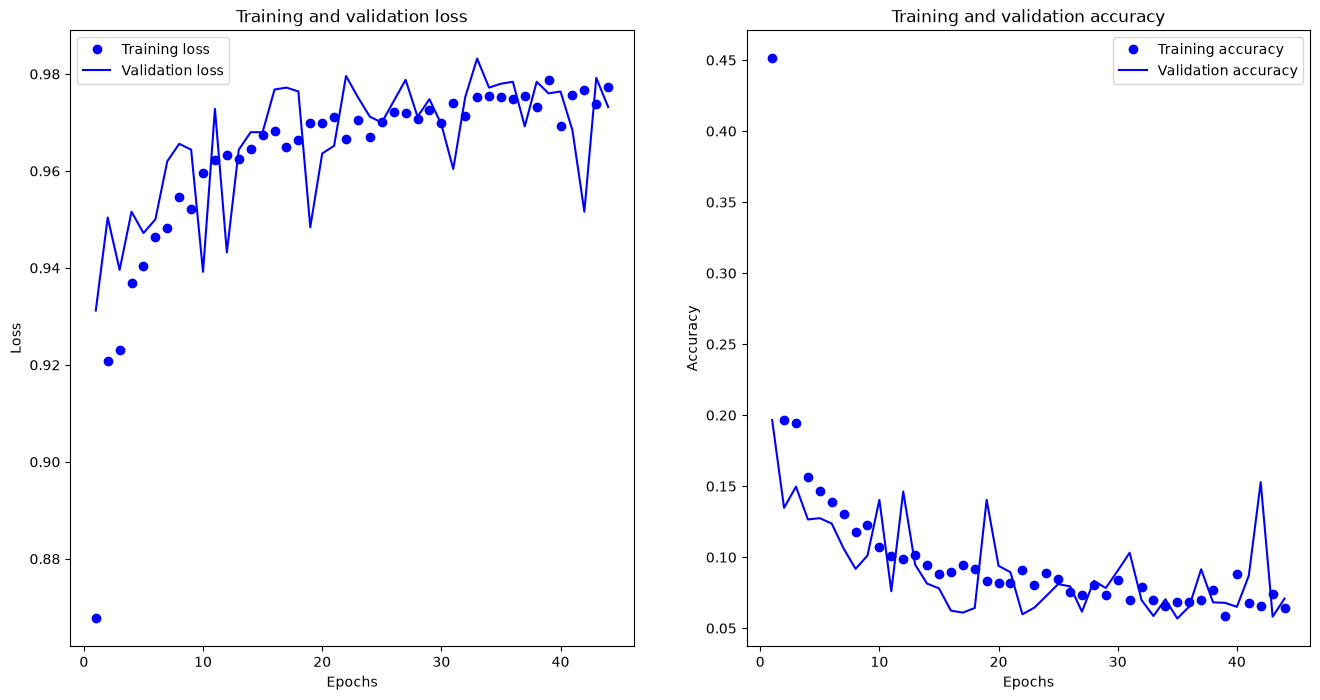

In [55]:
plot_model_training_history(tm.obter_historico())

### Modelo beta (create_model_beta)

Modelo próprio, projetado para **superar 90% de acurácia**. Nesta versão **GPU** ele ganha *data augmentation* e sai com a camada final em `float32` (exigência do *mixed precision*).

Diferenças-chave em relação aos modelos anteriores:

- **Normalização interna** (`Rescaling(1./255)`): os modelos 1-3 treinam com pixels crus (0-255), o que atrapalha a convergência. Aqui a normalização é uma camada do próprio modelo, então a chamada continua idêntica (`train_validate_and_test` recebe `x_train` cru).
- **Data augmentation** (`RandomFlip` + `RandomRotation`): gera variações espelhadas/rotacionadas a cada época — válido porque imagens aéreas não têm orientação fixa. Só age no treino e melhora a generalização praticamente de graça na GPU.
- **Blocos convolucionais com `BatchNormalization`**: estabiliza e acelera o treino (converge em menos épocas).
- **`padding='same'` + filtros 3x3**: preserva informação nas bordas das imagens pequenas (28x28).
- **Dropout** antes da saída para reduzir overfitting.
- **Saída em `float32`**: sob *mixed precision* a última camada é forçada a float32 para estabilidade numérica do softmax.

Arquitetura enxuta (2 blocos conv 32 -> 64); na GPU o treino voa mesmo com o dataset completo.

In [56]:
from tensorflow.keras.layers import Rescaling, RandomFlip, RandomRotation   # normalização + data augmentation

def create_model_beta(class_count, print_summary=False):

  model = Sequential([
      Rescaling(1./255, input_shape=(28, 28, 4)),                    # normaliza pixels 0-255 -> 0-1
      RandomFlip('horizontal_and_vertical'),                        # espelha (imagens aereas nao tem orientacao fixa)
      RandomRotation(0.2),                                          # rotacao aleatoria (so age no treino)

      # bloco 1
      Conv2D(32, (3,3), padding='same', activation='relu'),         # convolução 32 filtros 3x3
      BatchNormalization(),                                         # normalização de lote
      Conv2D(32, (3,3), padding='same', activation='relu'),         # convolução 32 filtros 3x3
      BatchNormalization(),
      MaxPool2D((2,2)),                                             # 28x28 -> 14x14

      # bloco 2
      Conv2D(64, (3,3), padding='same', activation='relu'),         # convolução 64 filtros 3x3
      BatchNormalization(),
      Conv2D(64, (3,3), padding='same', activation='relu'),         # convolução 64 filtros 3x3
      BatchNormalization(),
      MaxPool2D((2,2)),                                             # 14x14 -> 7x7

      Flatten(),                                                    # achatamento p/ entrar em MLP
      Dense(128, activation='relu'),                                # camada oculta c/ 128 neurônios
      Dropout(0.4),                                                 # dropout de 40%
      Dense(class_count, activation='softmax', dtype='float32')                      # camada de saída c/ 6 neurônios
  ])

  model.compile('adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
  if print_summary:
      model.summary()

  return model

### Treino do modelo beta

Treina o `create_model_beta` por até 50 épocas com o mesmo `train_validate_and_test`, então ele entra automaticamente no `benchmark` e disputa o `best_model`. Graças à normalização interna e ao `BatchNormalization`, a acurácia de validação deve subir rápido nas primeiras épocas e ultrapassar os 90% pretendidos.

In [57]:
model = create_model_beta(class_count, print_summary=True)
tm = train_validate_and_test('beta', model, x_train_partial, y_train_partial,
                             x_validation, y_validation, x_test, y_test, epochs=50)


/home/alex/Desktop/Projeto_M3/pdi_m3_2/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,934 (1.79 MB)

 Trainable params: 468,550 (1.79 MB)

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 80ms/step - accuracy: 0.9181 - loss: 0.2666 - val_accuracy: 0.7796 - val_loss: 0.6314
Epoch 2/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9511 - loss: 0.1501

704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.9511 - loss: 0.1500 - val_accuracy: 0.9140 - val_loss: 0.2123
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.9610 - loss: 0.1221 - val_accuracy: 0.7996 - val_loss: 0.7134
Epoch 4/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9603 - loss: 0.1218

704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.9603 - loss: 0.1217 - val_accuracy: 0.9740 - val_loss: 0.0844
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.9716 - loss: 0.0815 - val_accuracy: 0.9384 - val_loss: 0.1578
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.9679 - loss: 0.0967 - val_accuracy: 0.9004 - val_loss: 0.2592
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.9732 - loss: 0.0793 - val_accuracy: 0.9660 - val_loss: 0.0914
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.9756 - loss: 0.0767 - val_accuracy: 0.7956 - val_loss: 0.8835
Epoch 9/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.9760 - loss: 0.0838 - val_accuracy: 0.9472 - val_loss: 0.1509
Epoch 10/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.9770 - loss: 0.0697 - val_accuracy: 0.9476 - val_loss: 0.1570
Epoch 11/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.9792 - loss: 0.0623 - val_accur

704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.9819 - loss: 0.0555 - val_accuracy: 0.9744 - val_loss: 0.0599
Epoch 13/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.9774 - loss: 0.0754 - val_accuracy: 0.7628 - val_loss: 0.5348
Epoch 14/50
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9795 - loss: 0.0668

704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 86ms/step - accuracy: 0.9795 - loss: 0.0668 - val_accuracy: 0.9888 - val_loss: 0.0327
Epoch 15/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9846 - loss: 0.0466 - val_accuracy: 0.9732 - val_loss: 0.0753
Epoch 16/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9871 - loss: 0.0391 - val_accuracy: 0.9876 - val_loss: 0.0364
Epoch 17/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9856 - loss: 0.0455 - val_accuracy: 0.9880 - val_loss: 0.0409
Epoch 18/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.9868 - loss: 0.0393 - val_accuracy: 0.9776 - val_loss: 0.0478
Epoch 19/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9851 - loss: 0.0444 - val_accuracy: 0.9656 - val_loss: 0.1258
Epoch 20/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 88ms/step - accuracy: 0.9880 - loss: 0.0351 - val_accuracy: 0.9812 - val_loss: 0.0654
Epoch 21/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 61s 87ms/step - accuracy: 0.9893 - loss: 0.0329 - val_

Plota perda e acurácia do modelo beta. O esperado são as duas curvas de acurácia (treino e validação) altas e próximas — sinal de bom ajuste, sem overfitting acentuado.

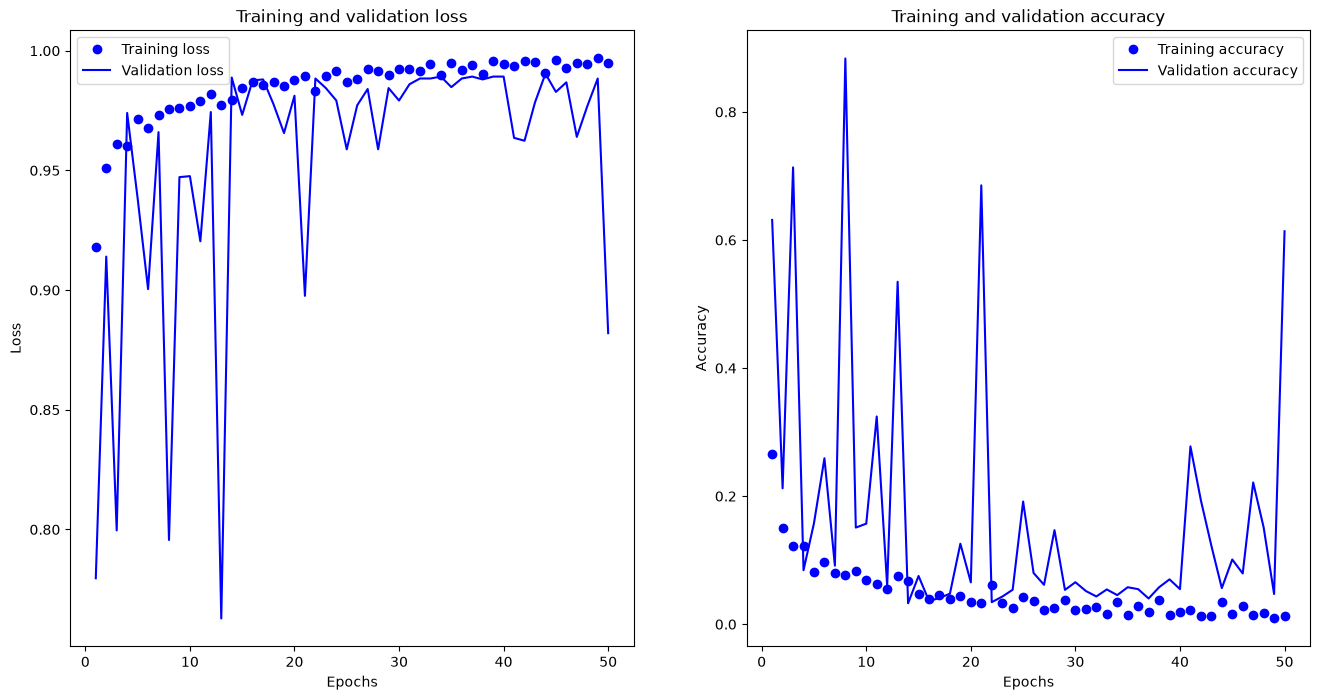

In [58]:
plot_model_training_history(tm.obter_historico())

### Tabela comparativa dos modelos

Monta um `DataFrame` a partir do dicionário `benchmark` (preenchido a cada `train_validate_and_test`) com acurácia, perda e tempo de treino de cada modelo, ordenado da maior para a menor acurácia. É o quadro que responde à pergunta central do trabalho: **qual arquitetura teve o melhor custo-benefício**.

In [ ]:
# tabela comparativa dos modelos (ordenada por acurácia)
df_resultados = pd.DataFrame({
    'Modelo': list(benchmark.keys()),
    'Acurácia': [v[0] for v in benchmark.values()],
    'Perda': [v[1] for v in benchmark.values()],
    'Tempo (s)': [v[2] for v in benchmark.values()],
}).set_index('Modelo').sort_values('Acurácia', ascending=False)

melhor = df_resultados.index[0]
print(f"Melhor modelo: '{melhor}'  ->  {df_resultados.loc[melhor, 'Acurácia']:.2%} de acuracia\n")

(df_resultados.style
    .format({'Acurácia': '{:.2%}', 'Perda': '{:.4f}', 'Tempo (s)': '{:.1f}'})
    .highlight_max(subset=['Acurácia'], color='#c8e6c9'))

### Resumo do melhor modelo

Imprime a arquitetura (camadas, formatos de saída e nº de parâmetros) do `best_model` — o modelo de maior acurácia, selecionado automaticamente durante os treinos. Documenta qual rede venceu e o seu tamanho.

In [60]:
best_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         4,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,340 (298.21 KB)

 Trainable params: 25,446 (99.40 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,894 (198.81 KB)

### Predições no conjunto de teste

`best_model.predict` devolve, para cada imagem, um vetor com a probabilidade das 6 classes; `np.argmax(..., axis=1)` escolhe a classe de maior probabilidade, produzindo `y_pred` (rótulos previstos). Esse vetor é a base para a matriz de confusão e as métricas a seguir.

In [61]:
y_pred = np.argmax(best_model.predict(x_test), axis=1)
y_pred

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


array([5, 5, 4, ..., 4, 3, 2], shape=(25000,))

#### Persistir modelo em disco


> n deu boa

In [62]:
#best_model.save('best_model')

#### Matriz de confusão

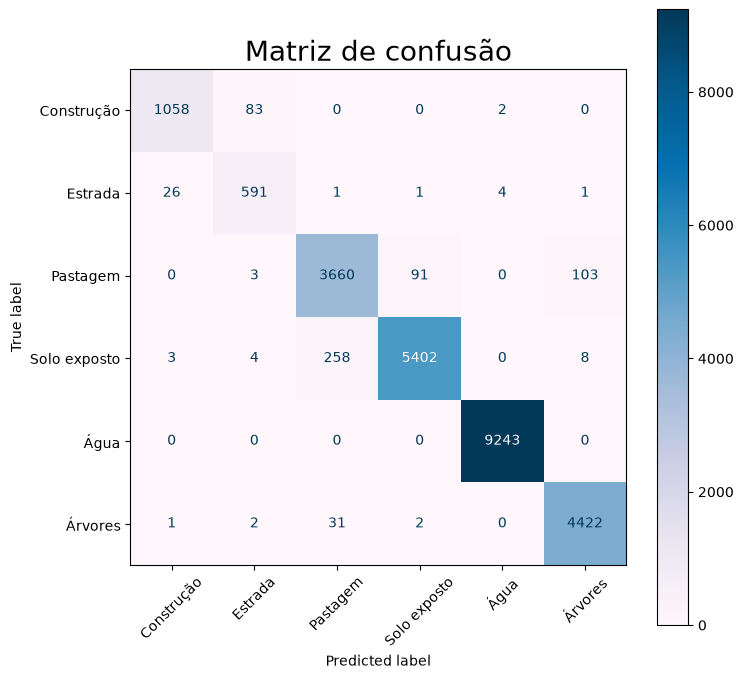

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8,8))

cm = confusion_matrix(y_test, y_pred)
cmp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cmp = cmp.plot(include_values=True, cmap='PuBu', ax=ax, xticks_rotation=45)

plt.title('Matriz de confusão', fontsize=20)
plt.grid(False)
plt.show()

### Matriz de confusão normalizada (mlxtend)

Gera a mesma matriz de confusão, agora com a biblioteca `mlxtend` e `show_normed=True`, exibindo as **proporções por linha** (percentual de acerto/erro dentro de cada classe verdadeira). A versão normalizada facilita comparar classes com quantidades de amostras muito diferentes — útil dado o desbalanceamento do dataset.

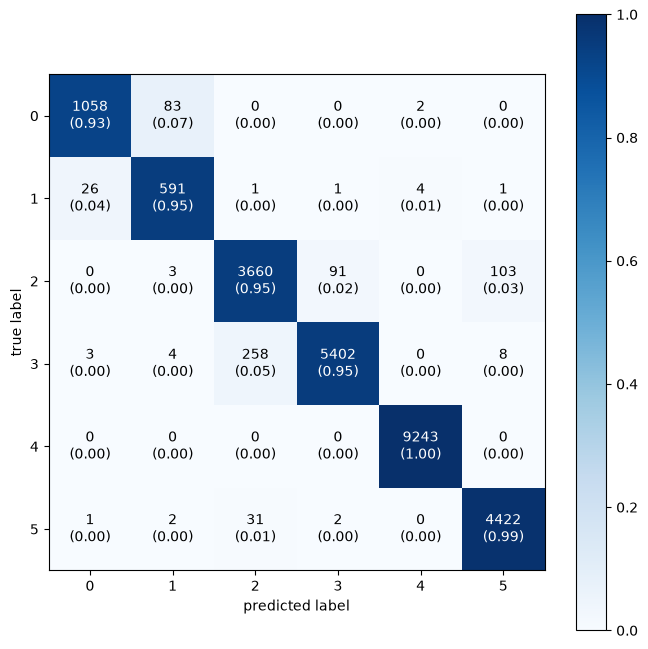

In [64]:
from mlxtend.evaluate import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

cm = confusion_matrix(y_target=y_test, y_predicted=y_pred, binary=False)
plot_confusion_matrix(cm, figsize=(8, 8), show_normed=True, colorbar=True)
plt.show()

#### Metricas de Desempenho

In [65]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve

### Métricas de desempenho consolidadas

Imprime acurácia, precisão, revocação e F1-score comparando `y_test` com `y_pred`. Usa `average='weighted'`, que calcula a métrica por classe e faz a média **ponderada pelo nº de amostras** de cada uma — a escolha mais honesta com classes desbalanceadas, pois evita que uma classe rara distorça o resultado. O ROC AUC está comentado por exigir as probabilidades, não os rótulos já decididos.

In [66]:
# exibir valores das métricas para o modelo
average_setting = 'weighted'
print("Métricas para o modelo:")
print("- Acurácia  = %.3f" % accuracy_score(y_test, y_pred))
print("- Precisão  = %.3f" % precision_score(y_test, y_pred, average=average_setting))
print("- Revocação = %.3f" % recall_score(y_test, y_pred, average=average_setting))
print("- F1-Score  = %.3f" % f1_score(y_test, y_pred, average=average_setting))
#print("- ROC AUC   = %.3f" % roc_auc_score(y_test, y_pred, multi_class='ovr', average=average_setting))

Métricas para o modelo:
- Acurácia  = 0.975
- Precisão  = 0.976
- Revocação = 0.975
- F1-Score  = 0.975


### Função: amostras classificadas incorretamente

Define `show_difference_samples`, que percorre `y_test` × `y_pred`, monta a lista dos índices onde o modelo **errou** e sorteia alguns para exibir em grade, mostrando no título a classe prevista e, entre parênteses, a verdadeira. Analisar os erros revela *onde* o modelo confunde (ex.: Pastagem × Árvores) e se os enganos fazem sentido visualmente.

In [67]:
def show_difference_samples(data, labels_true, labels_pred, plot_rows=4):

    # criar lista de respostas diferentes
    diff_indexes = []
    counter = 0
    for different in (labels_true != labels_pred):
        if different:
            diff_indexes.append(counter)
        counter += 1
    #available_classes = np.unique(labels_true[labels_true != labels_pred])

    chosen_indexes = []
    fig = plt.figure(figsize=(16, plot_rows * 2))
    ax = []
    rows, columns = plot_rows, 8
    for i in range(columns * rows):

        # sortear item da lista
        while True:
            index = diff_indexes[np.random.randint(0, len(diff_indexes))]
            label_true = labels_true[index]
            label_pred = labels_pred[index]
            if label_true != label_pred and index not in chosen_indexes:
                #print("index:", index, "-> label:", label_true, label_pred)
                #print(class_names[label_pred], "->", class_names[label_true])
                chosen_indexes.append(index)
                break

        # exibir imagem no gráfico
        img = data[index].reshape([28,28,4])[:,:,:3]
        ax.append(fig.add_subplot(rows, columns, i+1))
        ax[-1].set_title(str(index) + ": " + 
                         class_names[label_pred] + "\n(" + 
                         class_names[label_true] + ")", fontsize=11)
        plt.axis("off")
        plt.imshow(img)

    plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()


### Função: probabilidades de uma amostra

Define `show_sample_predictions`, que passa uma única imagem pelo modelo e devolve uma tabela com a probabilidade (%) de cada classe, ordenada da maior para a menor. Mostra a **confiança** da decisão — acertar com 99% é bem diferente de acertar 'por pouco' com 35%.

In [68]:
def show_sample_predictions(model, data, index):
    values = data[index].reshape([-1,28,28,4])
    predictions = np.round(model.predict(values)[0] * 100, 2)
    df = pd.DataFrame({'Classe': class_names, 'Predição': predictions})
    return df.sort_values(by='Predição', ascending=False)


Exibe 5 linhas de exemplos que o melhor modelo classificou errado, para inspeção qualitativa dos erros.

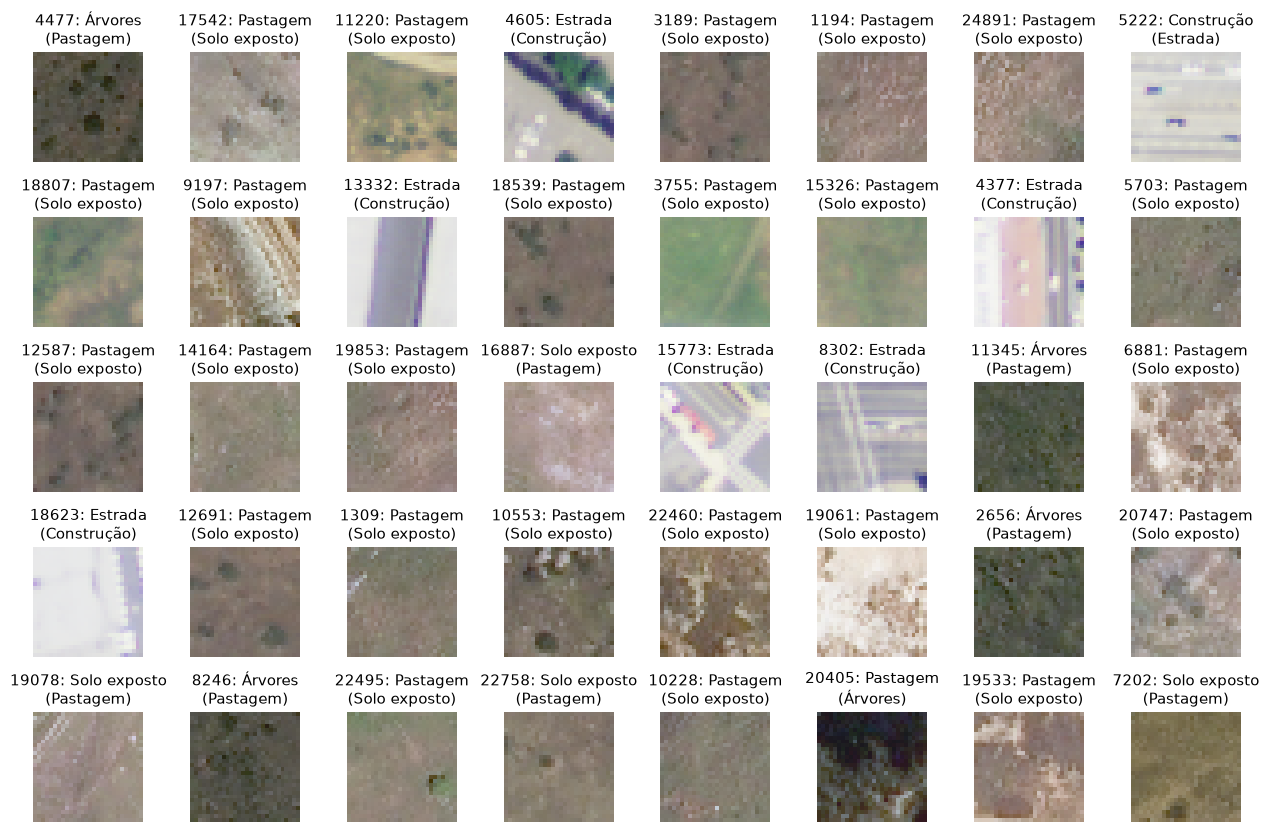

In [69]:
show_difference_samples(x_test, y_test, y_pred, plot_rows=5)

### Inspeção de amostras (histograma × predição)

Mostra a imagem RGB e o histograma dos 4 canais da amostra de teste nº 1739, para examinar sua assinatura espectral antes de olhar a decisão do modelo.

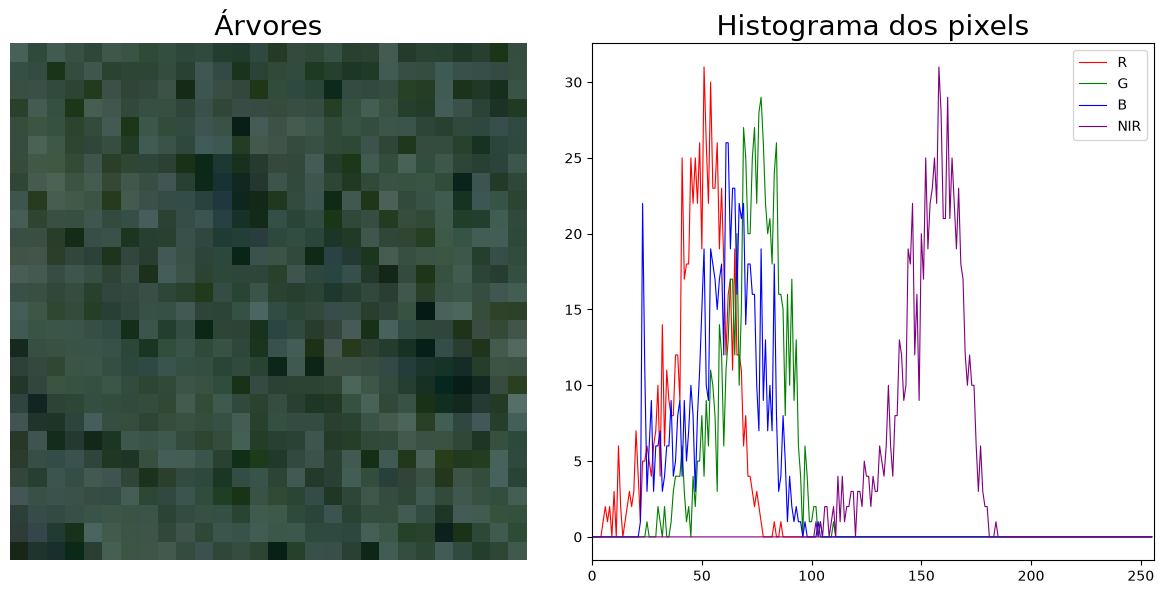

In [76]:
show_sample_histogram(x_test, y_test, index=1739)

Tabela de probabilidades do melhor modelo para a amostra de teste nº 17393 — quão confiante ele ficou em cada classe.

In [78]:
show_sample_predictions(best_model, x_test, 17393)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


,Classe,Predição
4,Água,100.0
0,Construção,0.0
1,Estrada,0.0
2,Pastagem,0.0
3,Solo exposto,0.0
5,Árvores,0.0


Imagem RGB + histograma espectral da amostra de teste nº 17393 (a mesma detalhada na predição acima), para cruzar o que o modelo 'viu' com o que decidiu.

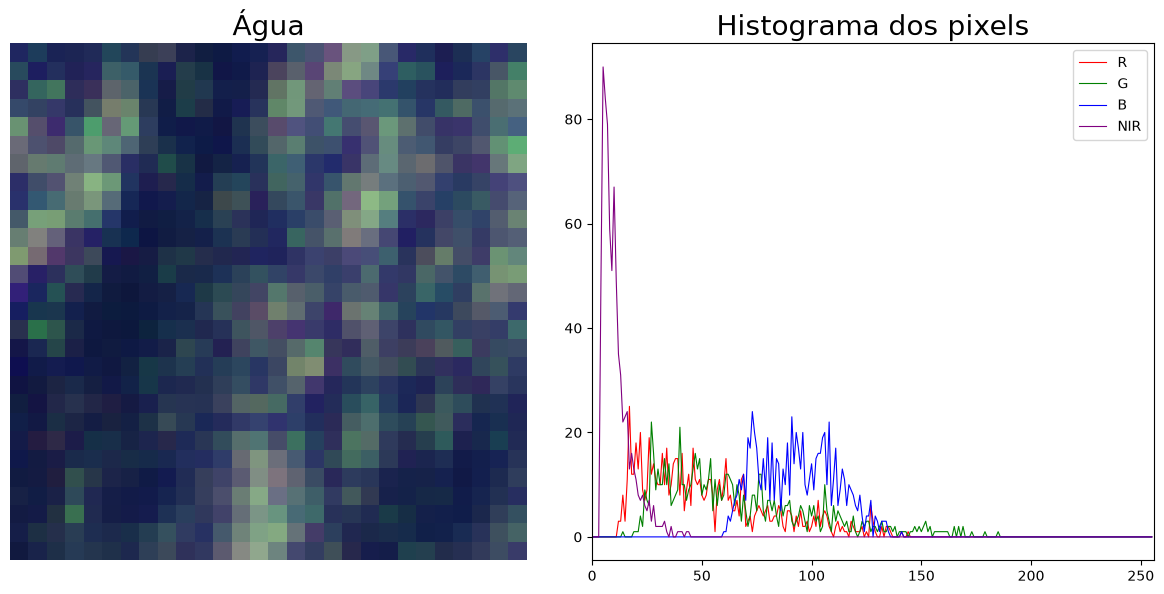

In [80]:
show_sample_histogram(x_test, y_test, index=17393)

Tabela de probabilidades do melhor modelo para a amostra de teste nº 45.

In [73]:
show_sample_predictions(best_model, x_test, 45)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


,Classe,Predição
4,Água,100.0
0,Construção,0.0
1,Estrada,0.0
2,Pastagem,0.0
3,Solo exposto,0.0
5,Árvores,0.0
